# 评分卡开发（中文）

本 Notebook 展示 P2 的实际评分卡产物。核心训练、交叉验证、分数换算和报告生成逻辑位于 `src/credit_risk/scorecard.py`，此处不复制业务逻辑。

评分卡采用训练折内重新拟合的 `WOETransformer → LogisticRegression`。`C` 只由固定训练集内部的五折交叉验证选择；验证集用于开发期比较，测试标签不参与。下方读取版本化元数据、逐折结果和箱分表，并用项目实现验证 600 分对应的原始 PD。

结果必须结合 `outputs/reports/scorecard_report.md` 解读。当前分数仅精确对应未校准的原始评分卡 PD，不代表审批策略、因果关系、合规拒绝理由或跨时期稳定性。

,mean_roc_auc,mean_brier_score,total_seconds
c_value,,,
0.01,0.773224,0.136284,0.658315
0.10,0.773076,0.136179,0.677190
1.00,0.772428,0.136228,0.742374
10.00,0.772128,0.136257,0.731314


,roc_auc,average_precision,ks,brier_score
ordinary_logistic,0.762873,0.537176,0.415618,0.136816
woe_scorecard,0.764752,0.527082,0.401422,0.138015


,feature,bin_label,woe,coefficient,points
0,sex,1,-0.106486,-0.084662,-0.650315
1,sex,2,0.072918,-0.084662,0.445317
2,education,1,0.186904,-0.216859,2.923746
3,education,2,-0.099610,-0.216859,-1.558204
4,education,3,-0.166408,-0.216859,-2.603120
5,education,OTHER,1.251590,-0.216859,19.578665
6,marital_status,1,-0.049811,-0.057196,-0.205508
7,marital_status,2,0.048090,-0.057196,0.198409
8,marital_status,OTHER,-0.201851,-0.057196,-0.832795
9,repayment_status_sep,-1,0.360923,-0.735286,19.143235


selected_c = 0.01
PD at score 600 = 0.04761904761904765


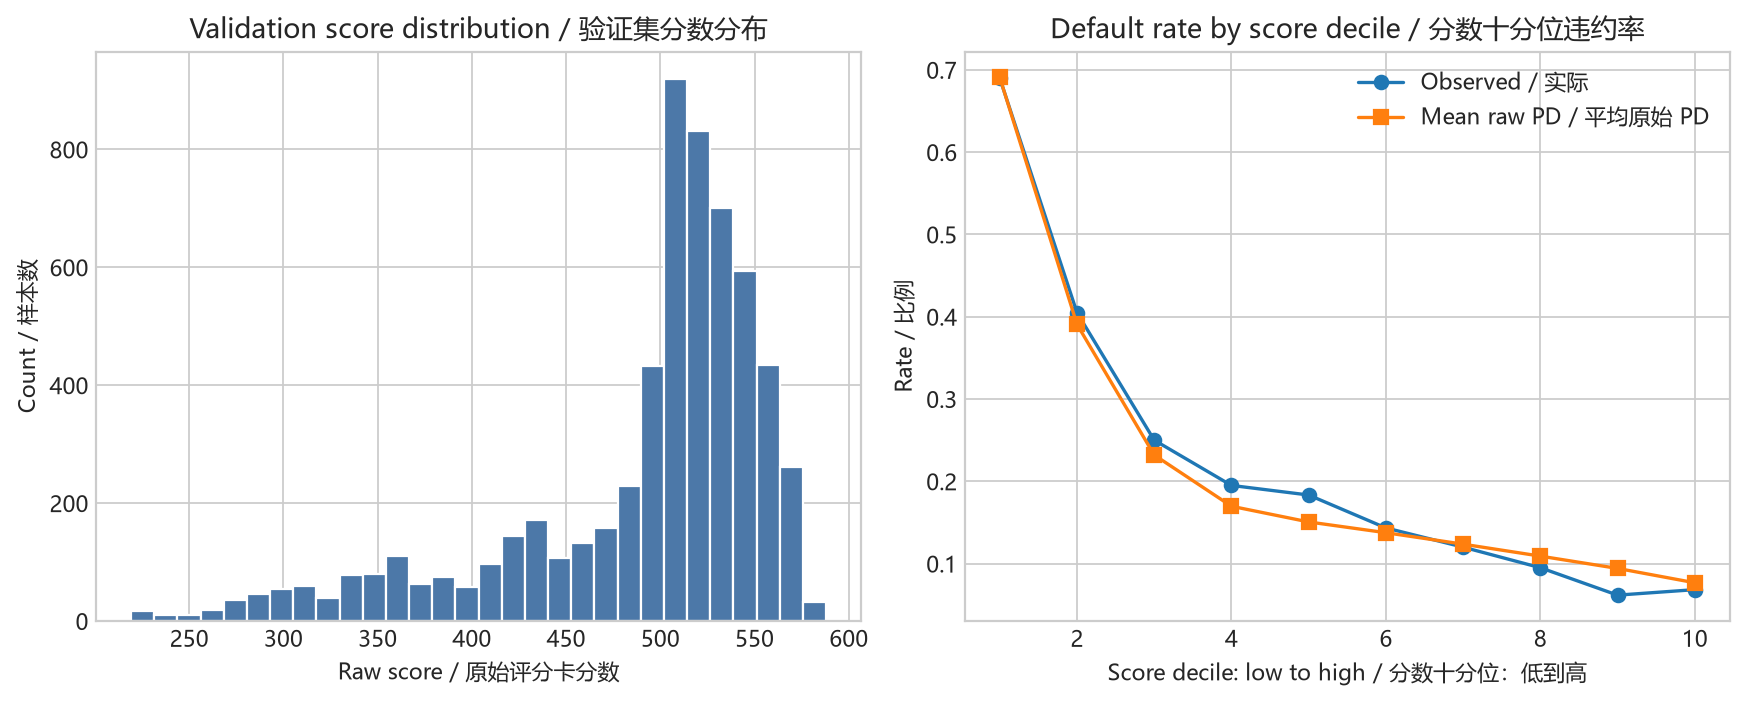

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from credit_risk.scorecard import ScoreMapping

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
artifact_dir = root / 'outputs' / 'artifacts' / 'p2_scorecard_20260921'
metadata = json.loads((artifact_dir / 'scorecard_metadata.json').read_text(encoding='utf-8'))
cv_results = pd.read_csv(artifact_dir / 'scorecard_cv_results.csv')
points = pd.read_csv(artifact_dir / 'scorecard_points.csv')

cv_summary = cv_results.groupby('c_value').agg(
    mean_roc_auc=('roc_auc', 'mean'),
    mean_brier_score=('brier_score', 'mean'),
    total_seconds=('fit_score_seconds', 'sum'),
)
display(cv_summary)
display(pd.DataFrame(metadata['validation_metrics']).T[['roc_auc', 'average_precision', 'ks', 'brier_score']])
display(points[['feature', 'bin_label', 'woe', 'coefficient', 'points']].head(12))
mapping = ScoreMapping(**{key: metadata['mapping'][key] for key in ('base_score', 'base_odds', 'pdo')})
print('selected_c =', metadata['selected_c'])
print('PD at score 600 =', mapping.score_to_probability(600.0))
display(Image(filename=str(root / 'outputs' / 'figures' / 'scorecard_validation.png')))

---

# Scorecard Development (English)

This notebook presents the actual P2 scorecard artifacts. Core training, cross-validation, score conversion, and report-generation logic lives in `src/credit_risk/scorecard.py`; business logic is not duplicated here.

The scorecard uses `WOETransformer → LogisticRegression`, refitted inside every training fold. `C` is selected only through five-fold cross-validation within the frozen training set. Validation supports development comparison, while test labels do not participate. The outputs above load versioned metadata, fold results, and bin points and use the project implementation to verify the raw PD associated with score 600.

Interpret the results together with `outputs/reports/scorecard_report.md`. The current score maps exactly only to the uncalibrated raw scorecard PD; it is not an approval policy, a causal finding, a compliant adverse-action reason, or evidence of temporal stability.